# vllm是一种性能优化架构

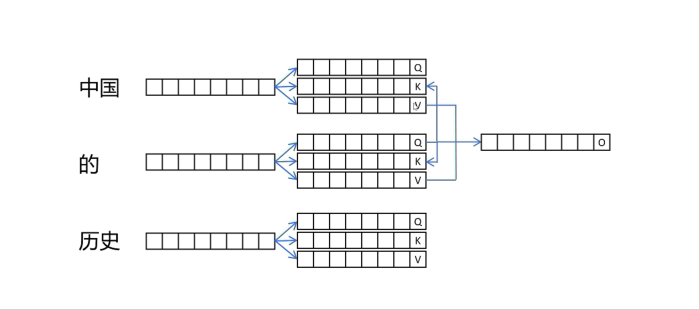
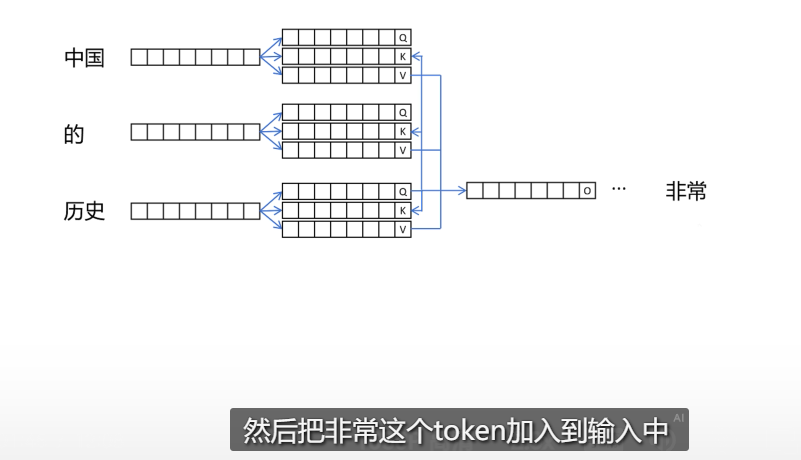

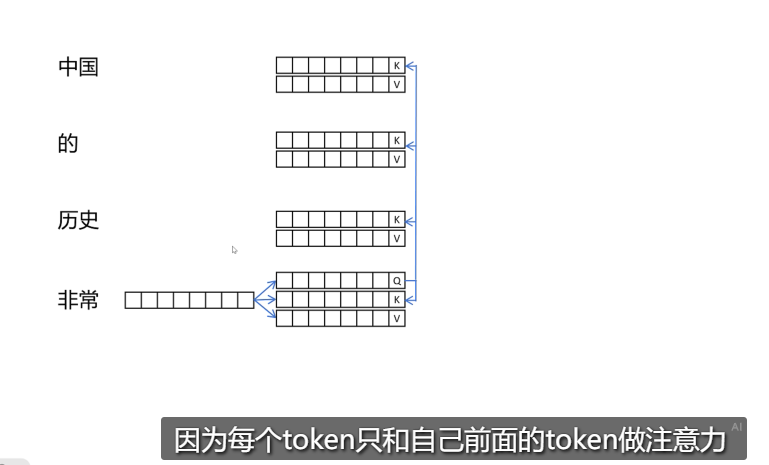

之前的三对KV都已经计算过了，结果不受新的token的影响。所以可以保存，不需要再次计算了，而且计算只需要前面的KV向量，所以只需要保存KV就可以

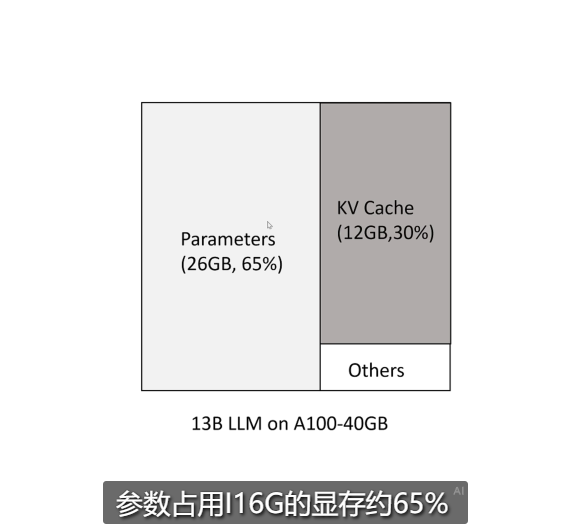
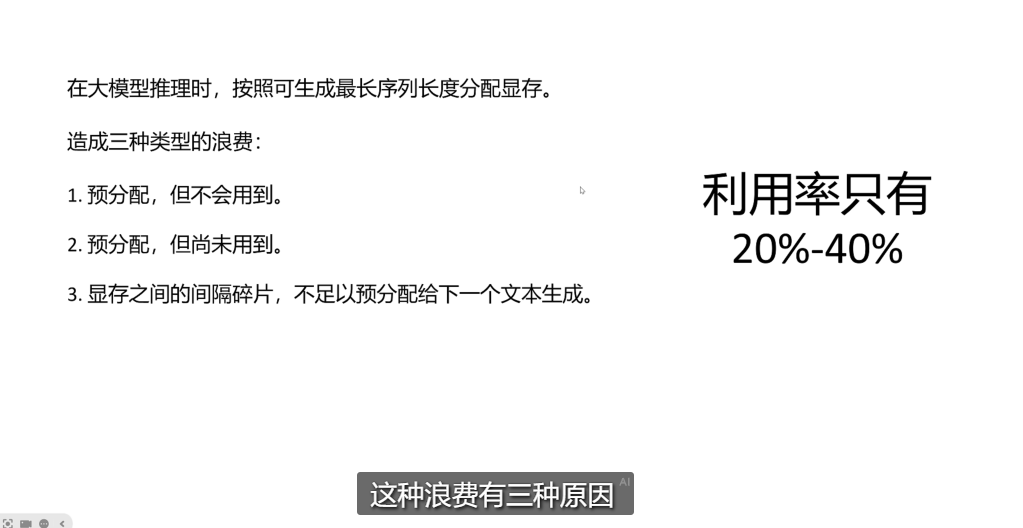

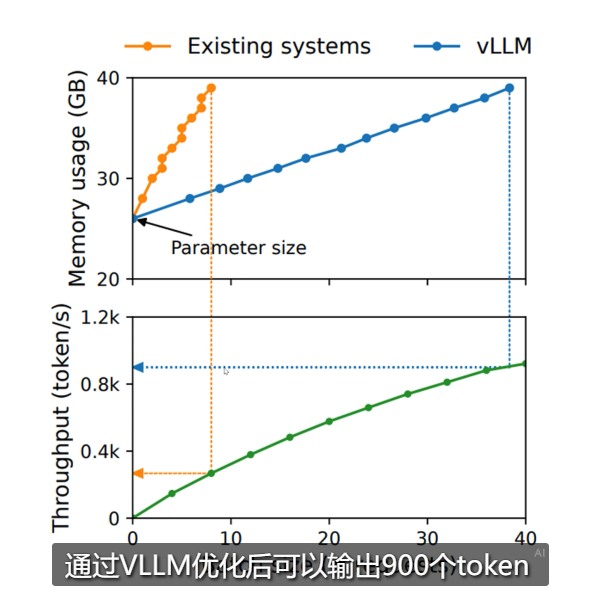

预分配KVcache 最大的token数1000，可能生成100个token就结束了，导致浪费

或者1000能到，但是前期生成的时候后面的都没有用到，但已经被占用。

prompt的长度不同，请求完毕释放，但是下一个的prompt比这个prompt更大，无法使用这个缓存，就是碎片。

# page attention

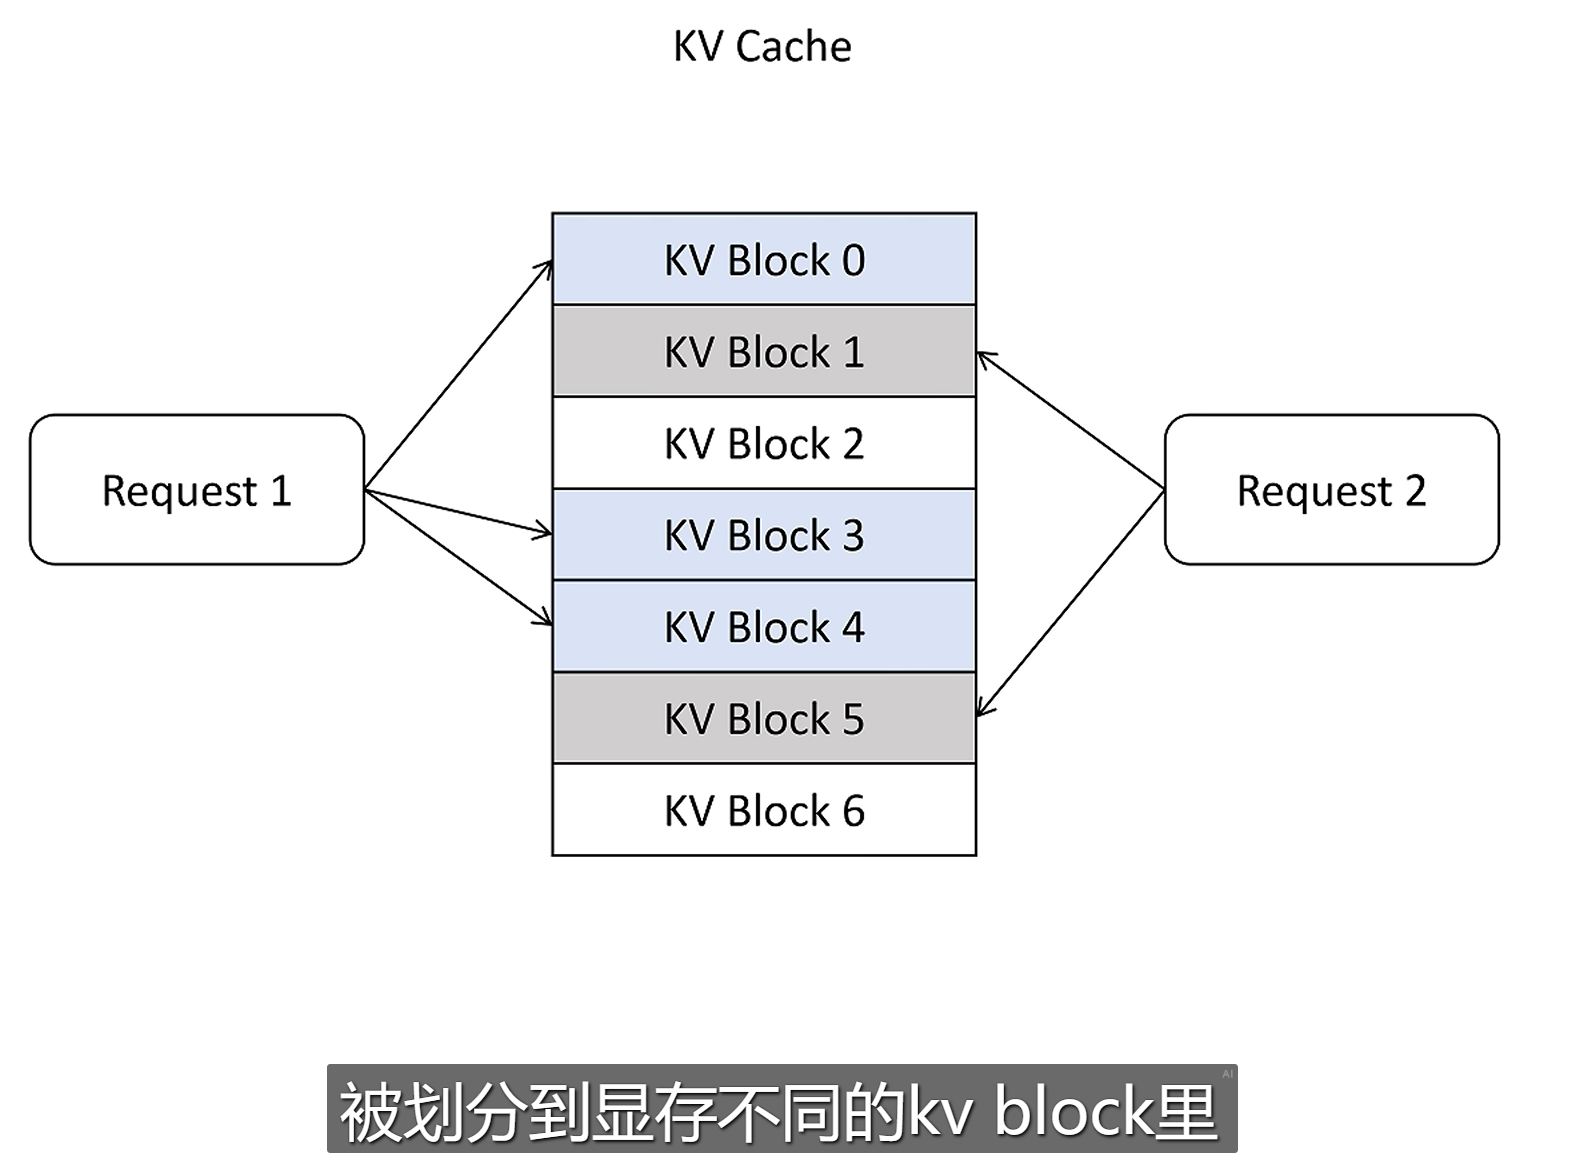
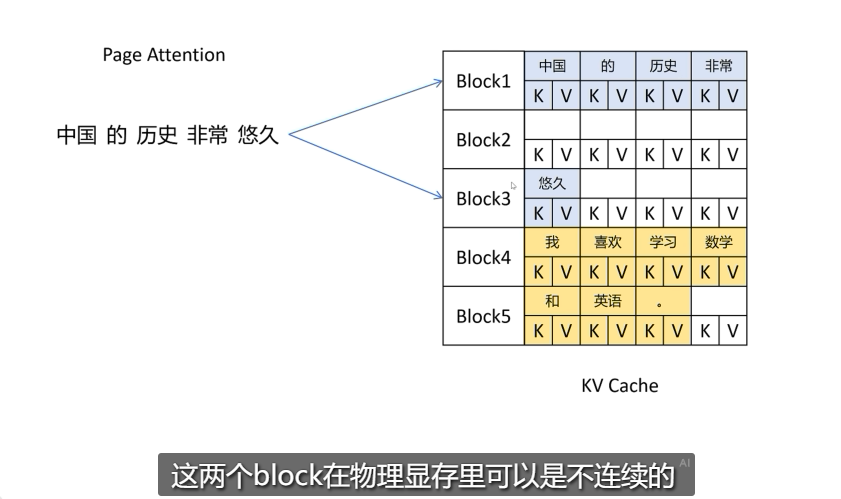
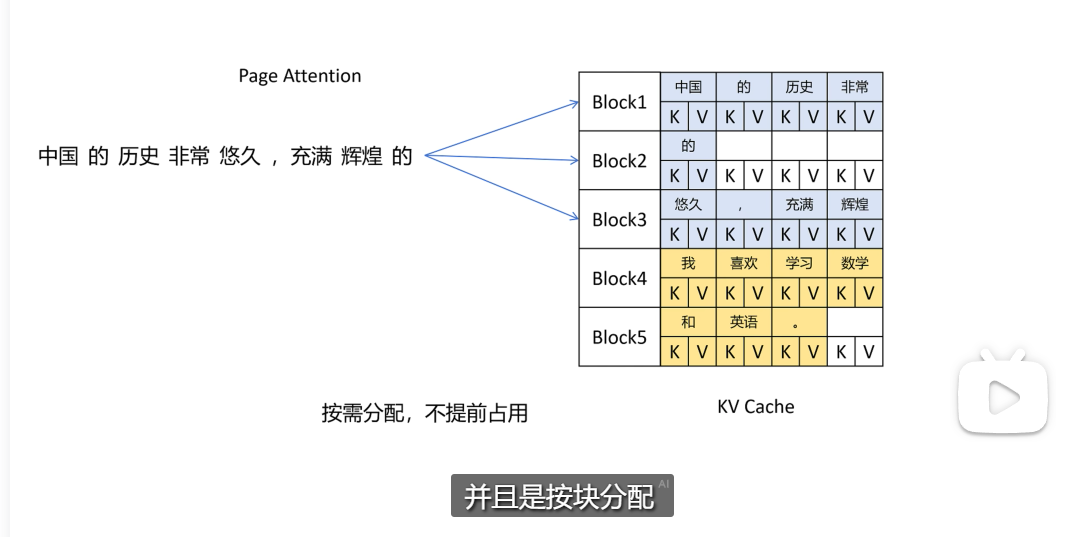

提前分配不连续的block，然后需要了才继续分配block，不提前占用。一个block4个token

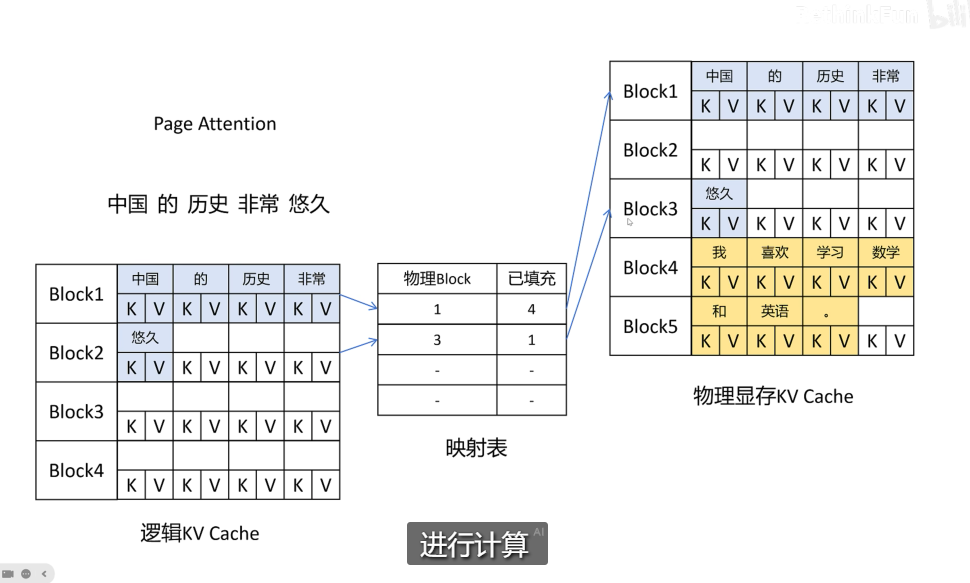
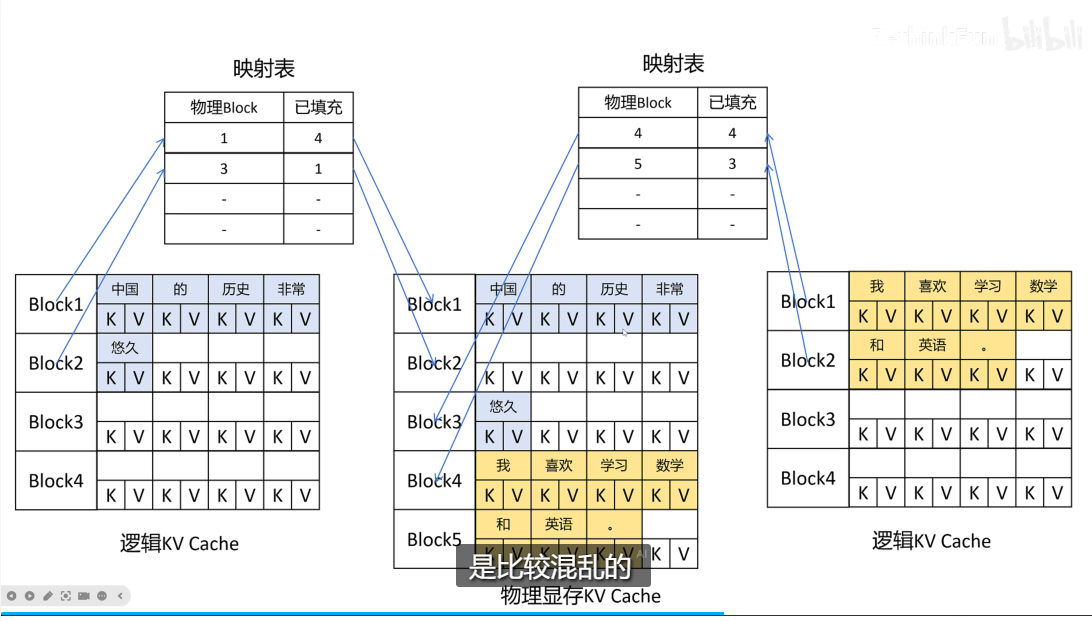
逻辑KV（虚拟内存）使得模型觉得使用的内存是 连续的（方便代码实现和调用）

实际通过映射表 它们的物理显存是不连续的

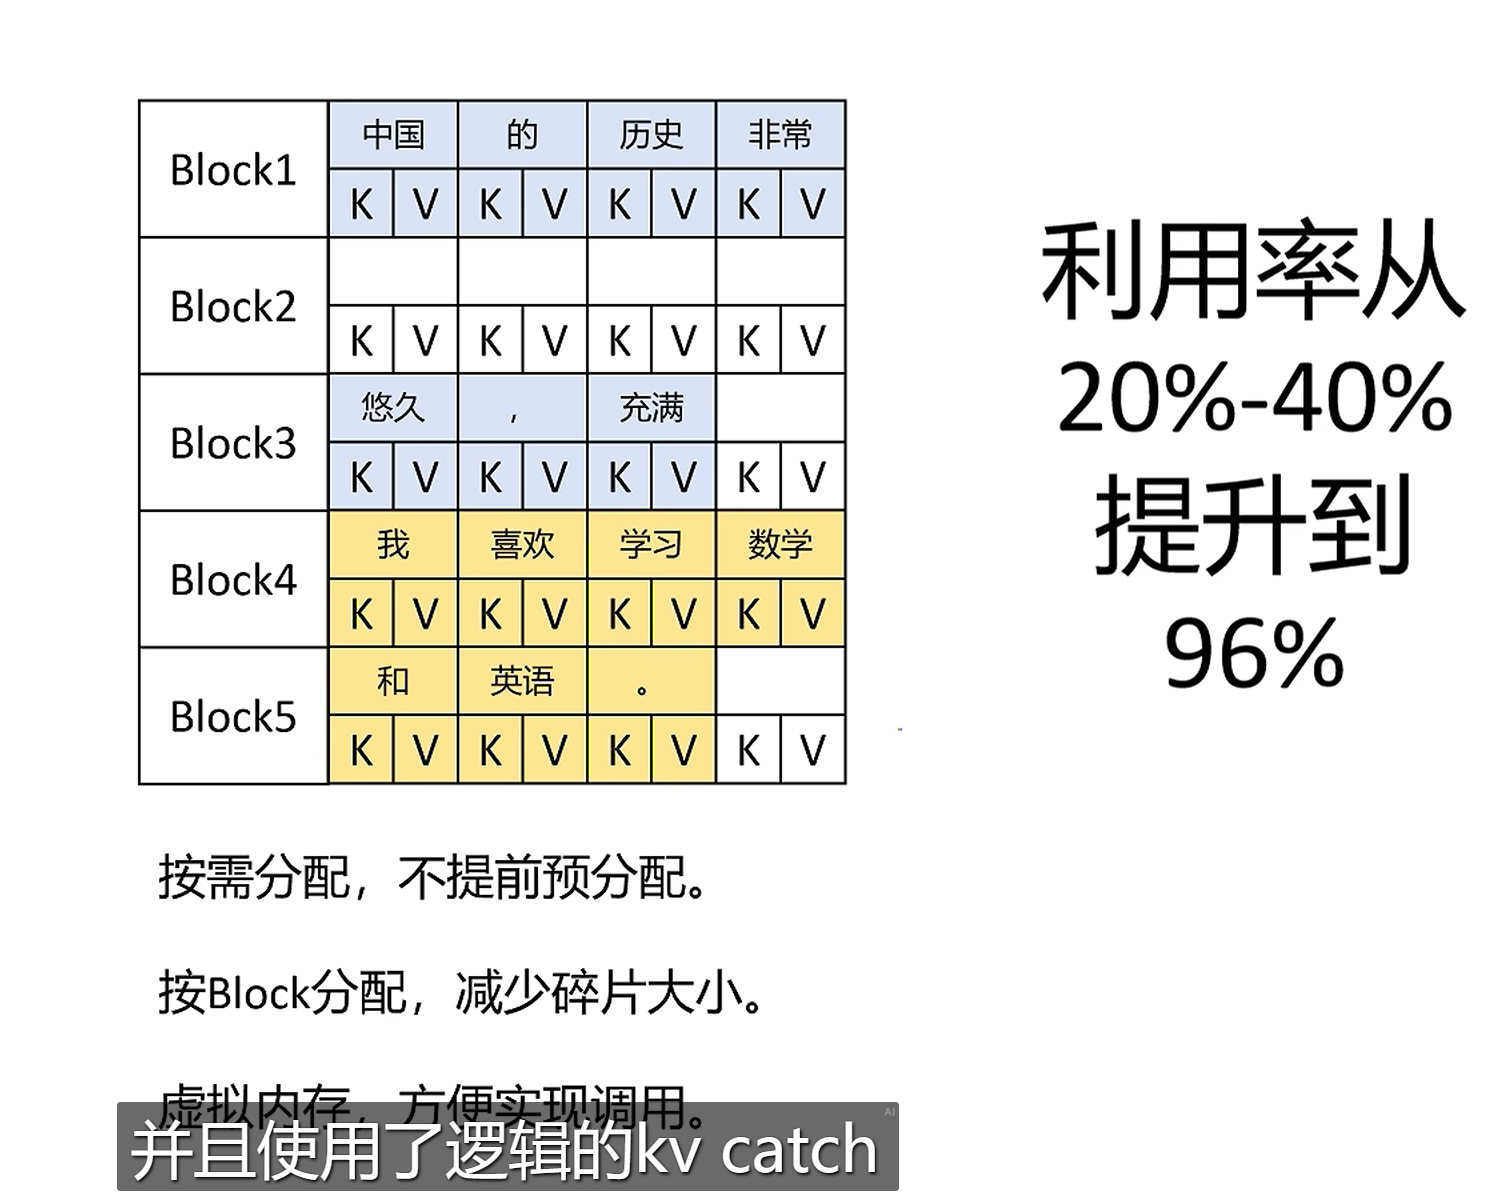

# vllm改进2 sharing KV BLocks

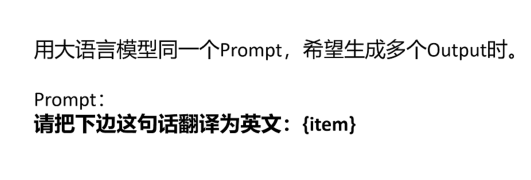

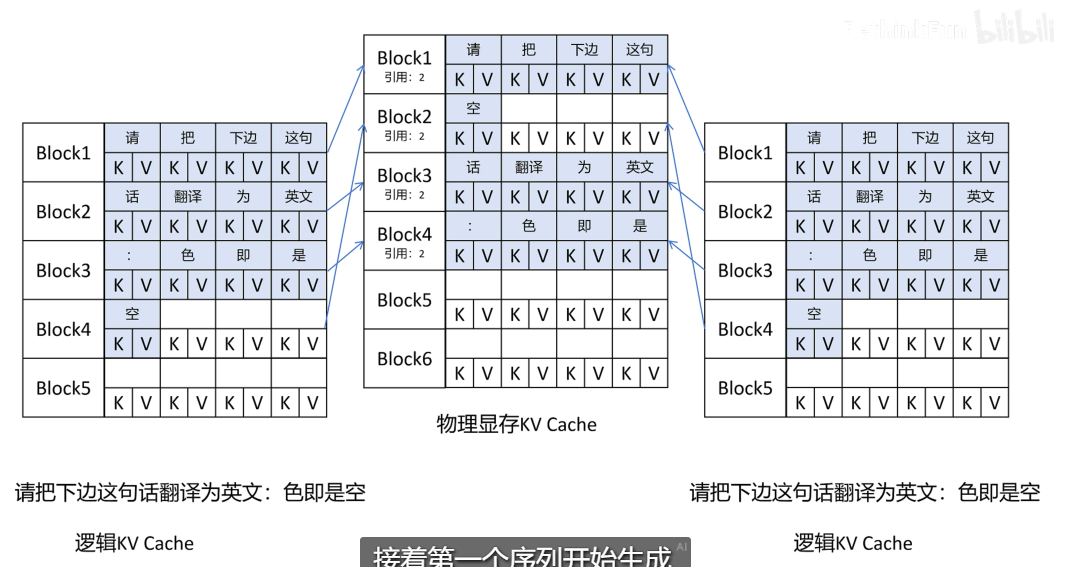

引用是2的时候它不能直接写入，引用为0才能够释放显存。不能直接写入必须拷贝一份来写（引用为1就能够直接写入了）

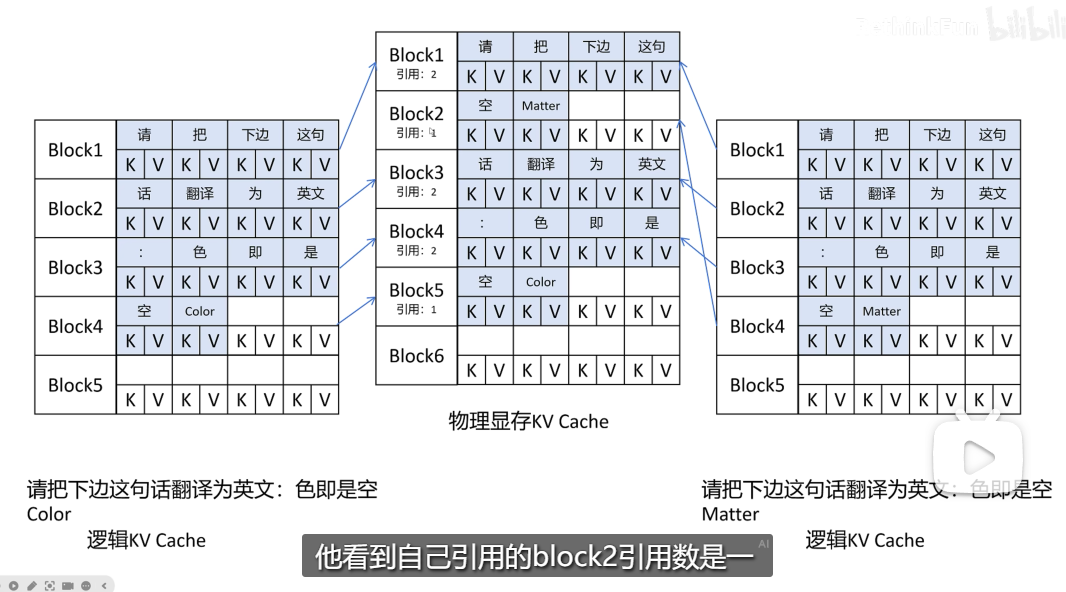

然后两个序列就各自往下生成，但是它们的prompt是共享的，节约了显存

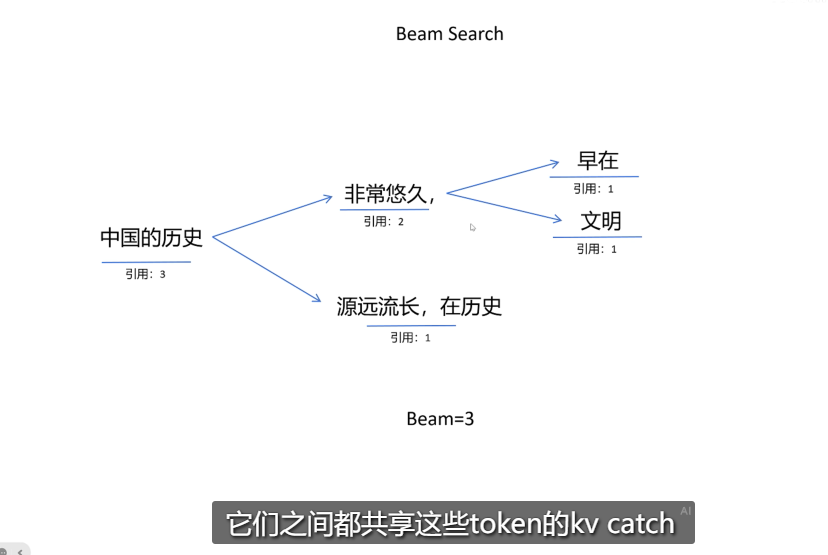

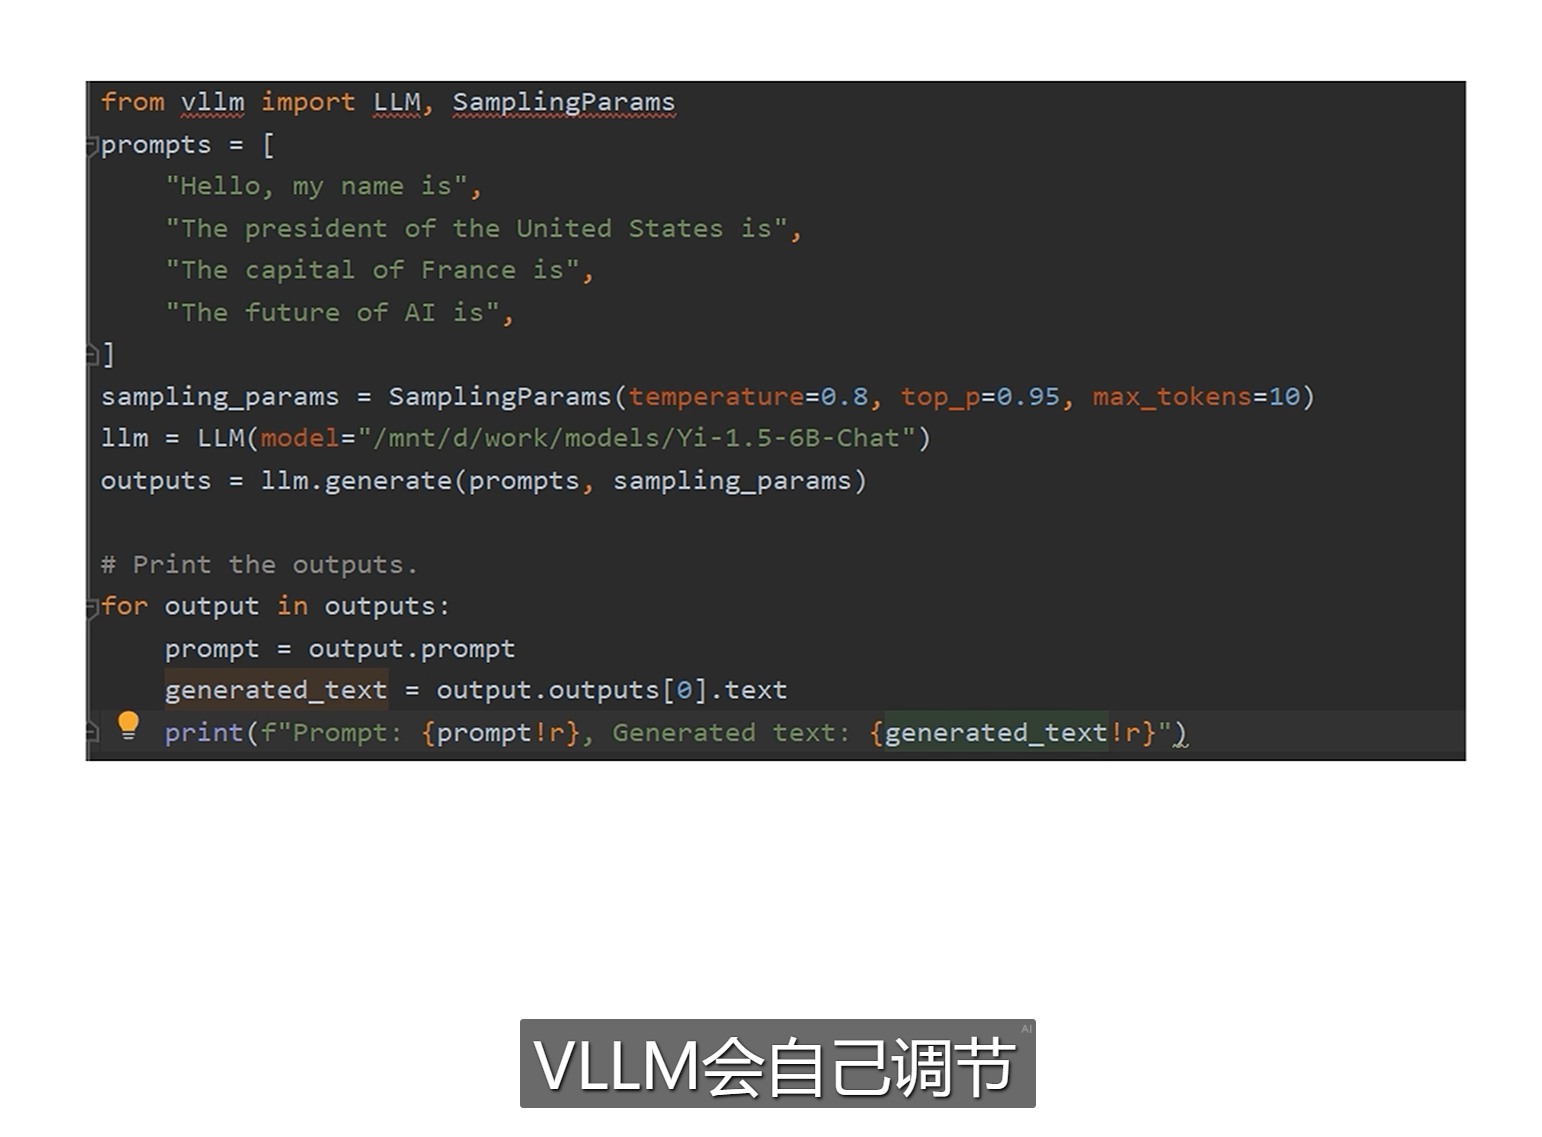